# 02 – Exploratory Data Analysis

## Project Overview

In this notebook, I explore the cleaned LinkedIn job postings dataset to better understand the relationships between job characteristics and salary.

The objectives of this analysis are to:

- Understand the distribution of salaries
- Explore relationships between salary and categorical features
- Identify trends across job titles, locations, and experience levels
- Generate insights that will guide feature engineering and model development

The findings from this notebook will inform the machine learning models built later in the project.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

In [2]:
# Load clean dataset
project_root = Path.cwd().parent

processed_dir = project_root / "data" / "processed"

df = pd.read_csv(processed_dir / "clean_jobs.csv")

df.head()

,title,location,formatted_work_type,formatted_experience_level,company_name,views,normalized_salary
0,Marketing Coordinator,"Princeton, NJ",Full-time,Unknown,Corcoran Sawyer Smith,20.0,38480.0
1,Mental Health Therapist/Counselor,"Fort Collins, CO",Full-time,Unknown,Unknown,1.0,83200.0
2,Assitant Restaurant Manager,"Cincinnati, OH",Full-time,Unknown,The National Exemplar,8.0,55000.0
3,Senior Elder Law / Trusts and Estates Associat...,"New Hyde Park, NY",Full-time,Unknown,"Abrams Fensterman, LLP",16.0,157500.0
4,Service Technician,"Burlington, IA",Full-time,Unknown,Unknown,3.0,70000.0


## Dataset Overview

Before creating visualizations, I first check the size and structure of the cleaned dataset.

In [3]:
df.shape

(35560, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35560 entries, 0 to 35559
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   title                       35560 non-null  str    
 1   location                    35560 non-null  str    
 2   formatted_work_type         35560 non-null  str    
 3   formatted_experience_level  35560 non-null  str    
 4   company_name                35560 non-null  str    
 5   views                       35560 non-null  float64
 6   normalized_salary           35560 non-null  float64
dtypes: float64(2), str(5)
memory usage: 1.9 MB


In [5]:
df.describe()

,views,normalized_salary
count,35560.000000,35560.000000
mean,19.466451,96728.356510
std,123.485464,60917.121679
min,1.000000,20000.000000
25%,3.000000,52340.600000
50%,5.000000,82500.000000
75%,10.000000,125000.000000
max,9975.000000,960000.000000


## Salary Distribution

I begin by examining the distribution of salaries to understand the range, spread, and potential outliers in the dataset.

Understanding the target variable is an important first step before developing machine learning models.

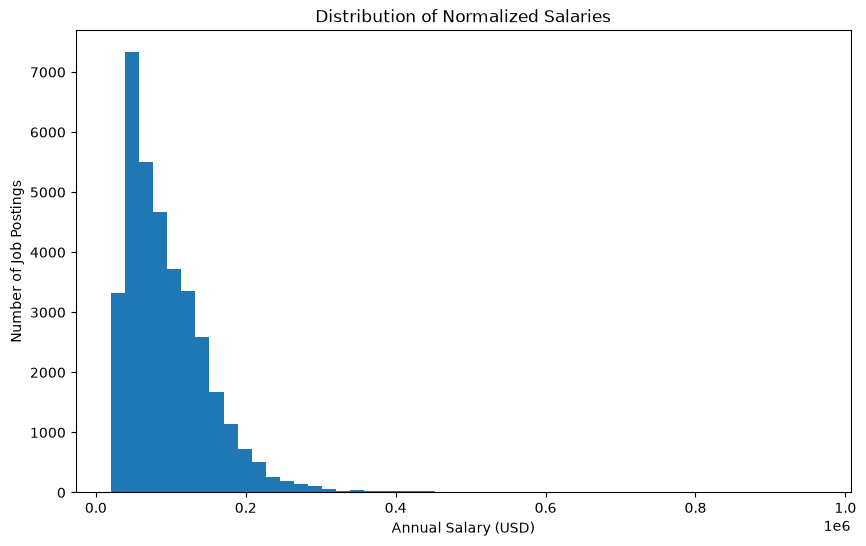

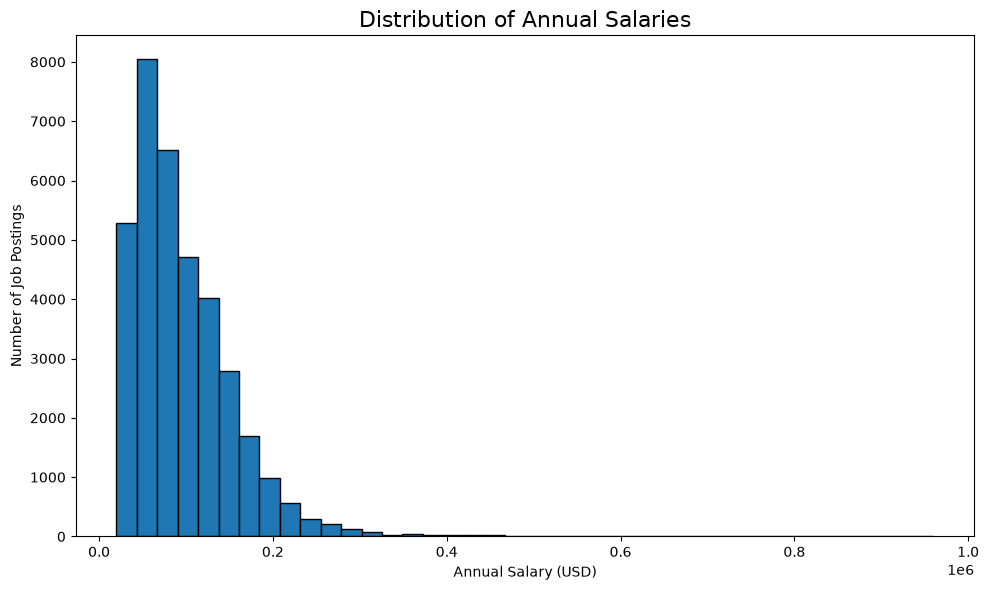

In [6]:
plt.figure(figsize=(10,6))

plt.hist(df["normalized_salary"], bins=50)

plt.title("Distribution of Normalized Salaries")

plt.xlabel("Annual Salary (USD)")

plt.ylabel("Number of Job Postings")

plt.figure(figsize=(10, 6))

plt.hist(
    df["normalized_salary"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Annual Salaries", fontsize=16)
plt.xlabel("Annual Salary (USD)")
plt.ylabel("Number of Job Postings")

plt.tight_layout()
plt.show()

### Interpretation

The distribution of annual salaries is positively (right) skewed, with most job postings concentrated between approximately **$40,000** and **$150,000** per year.

While a relatively small number of jobs offer substantially higher salaries, these observations form a natural upper tail rather than the extreme data quality issues identified during preprocessing.

The skewed distribution suggests that salary is not normally distributed, which is common in labor market data. This observation may influence future feature engineering and model selection.

## Salary by Experience Level

Experience level is expected to be one of the strongest predictors of salary.

To better understand this relationship, I compare the median salary across each experience level.

In [7]:
experience_salary = (
    df.groupby("formatted_experience_level")["normalized_salary"]
      .median()
      .sort_values()
)

experience_salary

formatted_experience_level
Internship           48880.0
Entry level          52500.0
Associate            74994.4
Unknown              78000.0
Mid-Senior level    108200.0
Director            167500.0
Executive           195000.0
Name: normalized_salary, dtype: float64

## Salary by Experience Level

After understanding the overall salary distribution, the next step is to examine how salary varies across different experience levels.

If experience level shows a strong relationship with compensation, it is likely to become one of the most important predictive features in the machine learning model. To investigate this relationship, I compare the median annual salary for each experience category.

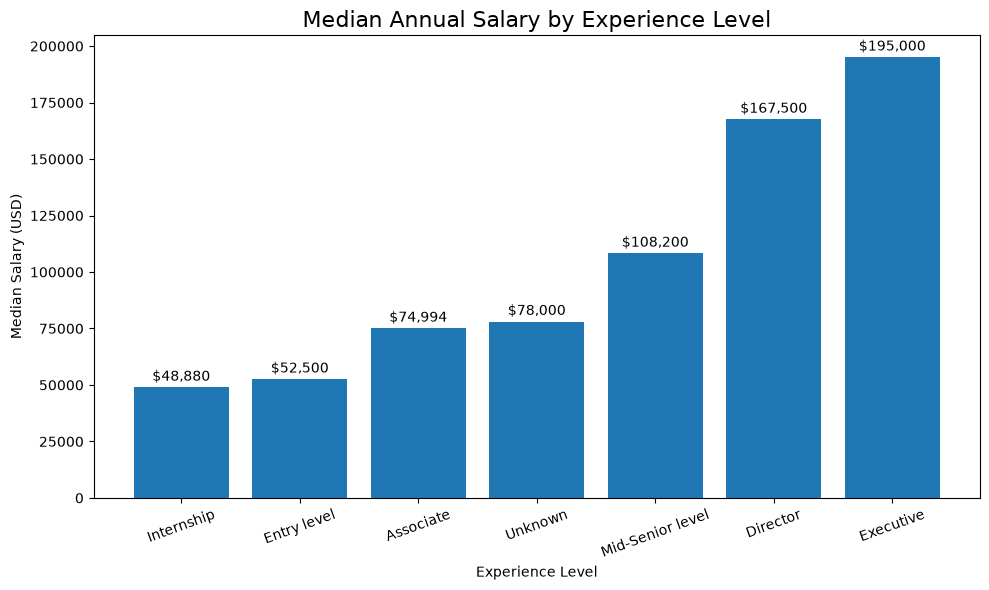

In [8]:
experience_salary = (
    df.groupby("formatted_experience_level")["normalized_salary"]
      .median()
      .sort_values()
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    experience_salary.index,
    experience_salary.values
)

plt.title("Median Annual Salary by Experience Level", fontsize=16)
plt.xlabel("Experience Level")
plt.ylabel("Median Salary (USD)")

plt.xticks(rotation=20)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 3000,
        f"${height:,.0f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Interpretation

A clear positive relationship exists between experience level and annual salary.

Entry-level and internship positions have the lowest median salaries, while director and executive roles earn substantially higher compensation. Mid-senior positions also show a notable increase compared to associate-level roles.

This trend aligns with expectations and suggests that **experience level is likely to be one of the strongest predictive features** in the salary prediction model.

## Salary by Work Type

After examining the relationship between salary and experience level, I next investigate whether compensation differs across work arrangements.

Different employment types—such as full-time, part-time, contract, and internship positions—often have distinct compensation structures. Comparing median salaries across work types provides additional insight into how employment arrangements relate to annual salary.

In [9]:
title_stats = (
    df.groupby("title")
      .agg(
          median_salary=("normalized_salary", "median"),
          job_count=("normalized_salary", "count")
      )
)

top_titles = (
    title_stats[title_stats["job_count"] >= 10]
    .sort_values("median_salary", ascending=False)
    .head(15)
)

top_titles

,median_salary,job_count
title,,
Chief Financial Officer,250000.0,19
Primary Care Physician,225000.0,10
Head of Sales,218750.0,10
Principal Software Engineer,199825.0,10
Remote Licensed Mental Health Counselor,187200.0,11
Licensed Mental Health Therapist,178880.0,10
Senior Site Reliability Engineer,166480.0,10
Senior Product Manager,165000.0,13
Java Developer,158000.0,10


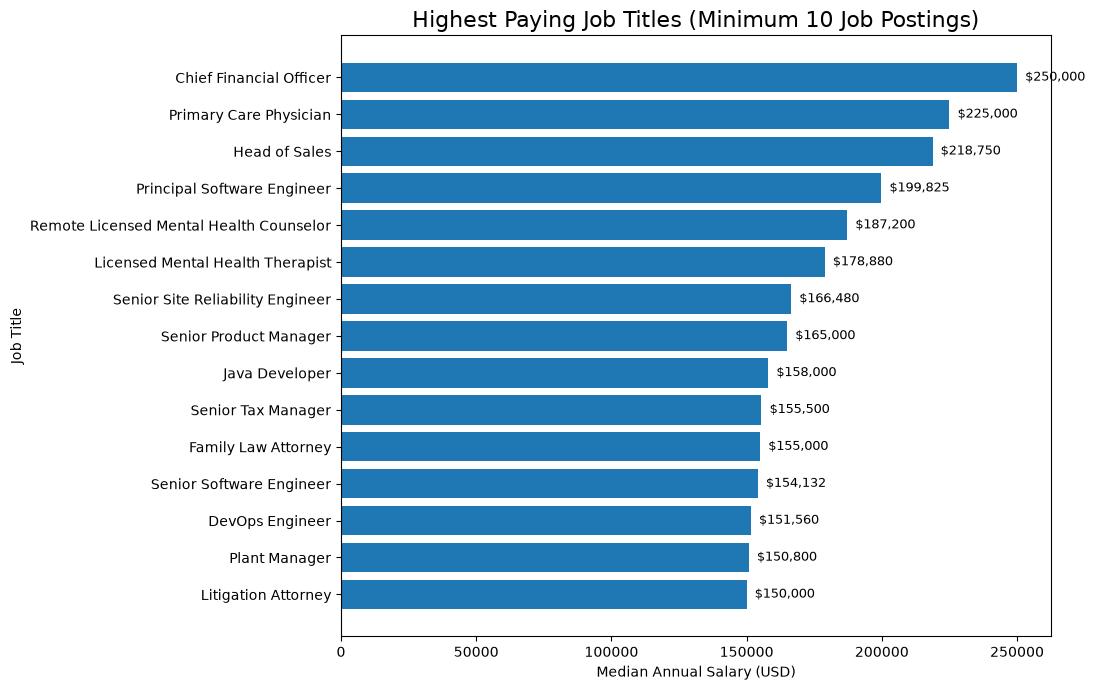

In [10]:
plt.figure(figsize=(11, 7))

bars = plt.barh(
    top_titles.index,
    top_titles["median_salary"]
)

plt.title("Highest Paying Job Titles (Minimum 10 Job Postings)", fontsize=16)
plt.xlabel("Median Annual Salary (USD)")
plt.ylabel("Job Title")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 3000,
        bar.get_y() + bar.get_height()/2,
        f"${width:,.0f}",
        va="center",
        fontsize=9
    )

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Interpretation

Among job titles with at least **10 job postings**, leadership positions, specialized technical roles, and healthcare professions consistently command the highest median salaries.

Executive and management positions, such as **Chief Financial Officer** and **Head of Sales**, appear near the top of the rankings, while highly specialized technical roles—including **Principal Software Engineer**, **Senior Site Reliability Engineer**, and **Senior Product Manager**—also offer substantially above-average compensation.

These findings suggest that **job title is one of the strongest predictors of annual salary**, making it an important feature for the machine learning models developed later in this project.

## Highest Paying Locations

Location is another factor that can significantly influence compensation because of differences in labor markets, industry concentration, and cost of living.

This analysis identifies the locations with the highest median salaries.

In [11]:
location_stats = (
    df.groupby("location")
      .agg(
          median_salary=("normalized_salary", "median"),
          job_count=("normalized_salary", "count")
      )
)

top_locations = (
    location_stats[location_stats["job_count"] >= 20]
    .sort_values("median_salary", ascending=False)
    .head(15)
)

top_locations

,median_salary,job_count
location,,
"San Mateo, CA",180366.0,33
"Mountain View, CA",162200.0,58
"Foster City, CA",159937.5,44
"Sunnyvale, CA",154500.0,98
San Francisco Bay Area,143750.0,148
"Rahway, NJ",143350.0,29
"San Jose, CA",140000.0,230
"Reston, VA",138765.0,46
"Palo Alto, CA",137717.5,67


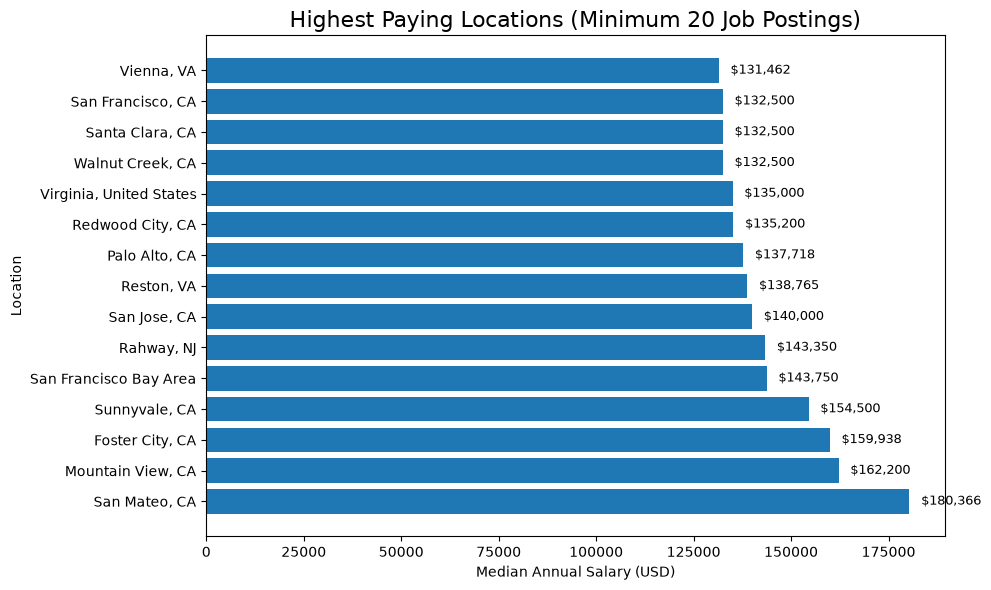

In [12]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_locations.index,
    top_locations["median_salary"]
)

plt.title("Highest Paying Locations (Minimum 20 Job Postings)", fontsize=16)
plt.xlabel("Median Annual Salary (USD)")
plt.ylabel("Location")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 3000,
        bar.get_y() + bar.get_height()/2,
        f"${width:,.0f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Interpretation

Among locations with at least **20 job postings**, the highest median salaries are concentrated in major technology hubs and metropolitan areas.

Several cities in California's Silicon Valley—including **San Mateo**, **Mountain View**, **Sunnyvale**, **San Jose**, **Palo Alto**, and **Santa Clara**—appear near the top of the rankings, reflecting the region's concentration of high-paying technology companies. Other locations, such as **Reston, VA** and **Rahway, NJ**, also demonstrate relatively high median salaries, likely due to strong technology, healthcare, and pharmaceutical industries.

These results indicate that **geographic location is an important factor influencing compensation** and is likely to improve salary prediction models.

## Most Common Job Titles

In addition to understanding which jobs pay the most, it is also helpful to understand which occupations appear most frequently in the dataset.

This provides context for the types of roles represented and highlights the diversity of occupations included in the analysis.

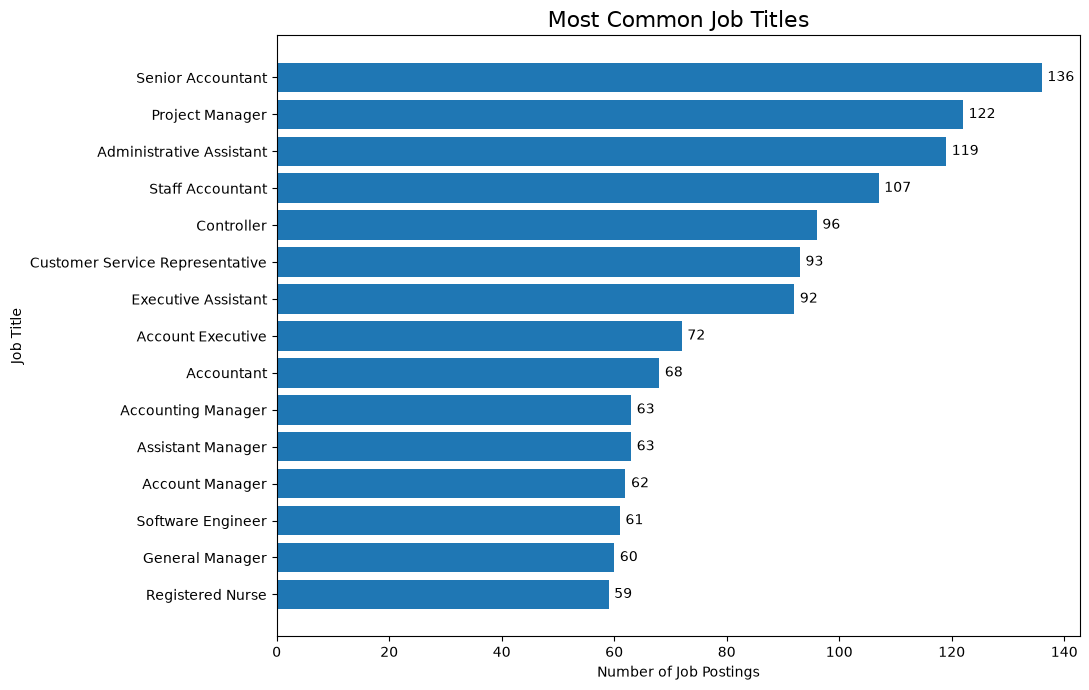

In [15]:
common_titles = (
    df["title"]
      .value_counts()
      .head(15)
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    common_titles.index,
    common_titles.values
)

plt.title("Most Common Job Titles", fontsize=16)
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Title")

# Add count labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center",
        fontsize=10
    )

# Highest count at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Interpretation

The dataset contains a diverse range of occupations, with accounting, finance, administrative, customer service, management, and software engineering roles appearing most frequently.

Positions such as **Senior Accountant**, **Project Manager**, **Administrative Assistant**, and **Software Engineer** occur regularly throughout the dataset, indicating that the data represents a broad cross-section of professional occupations rather than being concentrated within a single industry.

The diversity of job titles suggests that the machine learning models developed later in this project will be trained on a wide variety of occupations, improving their ability to generalize across different career fields.

## Relationship Between Job Posting Views and Salary

The dataset also includes the number of views each job posting received.

This section explores whether more highly viewed job postings tend to offer higher salaries or whether little relationship exists between posting popularity and compensation.

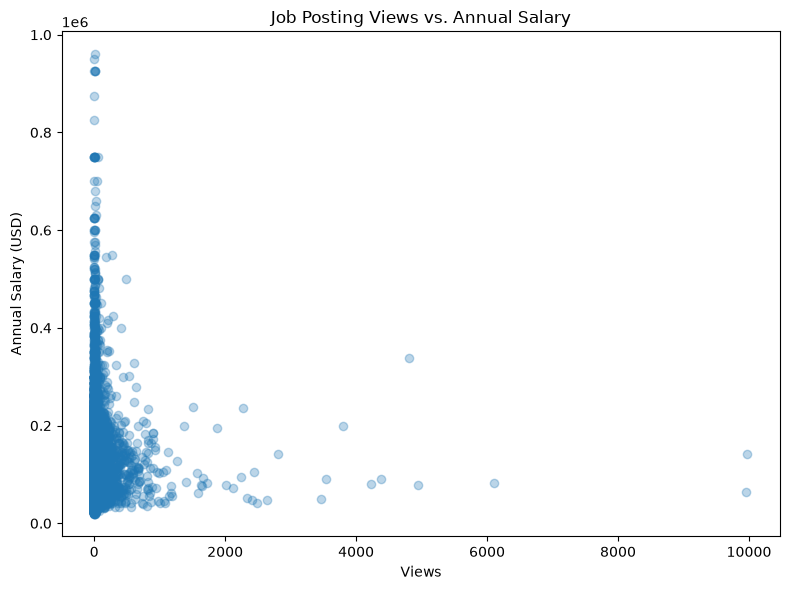

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["views"],
    df["normalized_salary"],
    alpha=0.3
)

plt.title("Job Posting Views vs. Annual Salary")
plt.xlabel("Views")
plt.ylabel("Annual Salary (USD)")

plt.tight_layout()
plt.show()

### Interpretation

The scatter plot does not reveal a strong linear relationship between the number of job posting views and annual salary.

While some high-paying positions receive relatively few views, several postings with thousands of views offer salaries closer to the dataset's median. Most job postings receive fewer than 500 views regardless of salary level, indicating that factors beyond compensation—such as company reputation, job location, industry, or posting visibility—likely influence the number of views.

Based on this exploratory analysis, **job posting views alone do not appear to be a strong predictor of annual salary**, although they may still provide some additional information when combined with other features.

# Summary

In this notebook, I explored the cleaned LinkedIn job postings dataset to better understand the factors associated with annual salary.

### Key Findings

- Annual salaries exhibit a positively skewed distribution, with most postings offering salaries between approximately **$40,000** and **$150,000**.
- Median salary generally increases with experience level, highlighting the importance of professional experience in determining compensation.
- Leadership positions, specialized technical roles, healthcare professionals, and legal occupations command some of the highest median salaries.
- High-paying jobs are concentrated in major technology hubs such as Silicon Valley, as well as other regions with strong technology, healthcare, and pharmaceutical industries.
- Job posting views show little evidence of a strong relationship with salary, suggesting that posting popularity alone is not a reliable indicator of compensation.
- The dataset contains a diverse collection of occupations across multiple industries, providing a strong foundation for predictive modeling.

Overall, this exploratory analysis identified several variables—including **job title, location, work type, and experience level**—that are likely to be valuable predictors in the machine learning models developed in the next notebook.